# 01 Exploratory data analysis

What fraud looks like in the training data, before any modelling.

**Findings**
- Fraud is 0.58% of transactions, so accuracy is useless as a metric.
- Median fraud amount is $396.51, vs $47.28 for genuine transactions.
- The fraud rate is about 2.9% between 22:00 and 23:59, vs about 0.1% during the day.
- Every merchant name starts with `fraud_`: a generator artifact, not a signal.

In [2]:
import pandas as pd

train = pd.read_csv("../data/raw/fraudTrain.csv", index_col=0)
test = pd.read_csv("../data/raw/fraudTest.csv", index_col=0)

print("Train:", train.shape, "| Test:", test.shape)
print(train.columns.tolist())

print(f"Train fraud rate: {train['is_fraud'].mean():.3%}")
print("Train dates:", train["trans_date_trans_time"].min(), "→", train["trans_date_trans_time"].max())
print("Test dates: ", test["trans_date_trans_time"].min(), "→", test["trans_date_trans_time"].max())

Train: (1296675, 22) | Test: (555719, 22)
['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
Train fraud rate: 0.579%
Train dates: 2019-01-01 00:00:18 → 2020-06-21 12:13:37
Test dates:  2020-06-21 12:14:25 → 2020-12-31 23:59:34


In [3]:
train["trans_date_trans_time"] = pd.to_datetime(train["trans_date_trans_time"])

print(train.dtypes)
print("Missing values:", train.isna().sum().sum())
print("Unique cards:", train["cc_num"].nunique())
print("All merchants start with 'fraud_':", train["merchant"].str.startswith("fraud_").all())

trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                              object
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object
Missing values: 0
Unique cards: 983
All merchants start with 'fraud_': True


In [4]:
print(train.groupby("is_fraud")["amt"].describe())

              count        mean         std   min       25%      50%      75%  \
is_fraud                                                                        
0         1289169.0   67.667110  154.007971  1.00    9.6100   47.280   82.540   
1            7506.0  531.320092  390.560070  1.06  245.6625  396.505  900.875   

               max  
is_fraud            
0         28948.90  
1          1376.04  


In [5]:
cat = (train.groupby("category")["is_fraud"]
       .agg(fraud_rate="mean", n="count")
       .sort_values("fraud_rate", ascending=False))
print(cat)

                fraud_rate       n
category                          
shopping_net      0.017561   97543
misc_net          0.014458   63287
grocery_pos       0.014098  123638
shopping_pos      0.007225  116672
gas_transport     0.004694  131659
misc_pos          0.003139   79655
grocery_net       0.002948   45452
travel            0.002864   40507
entertainment     0.002478   94014
personal_care     0.002424   90758
kids_pets         0.002114  113035
food_dining       0.001651   91461
home              0.001608  123115
health_fitness    0.001549   85879


<Axes: title={'center': 'Fraud rate by hour of day'}, xlabel='hour'>

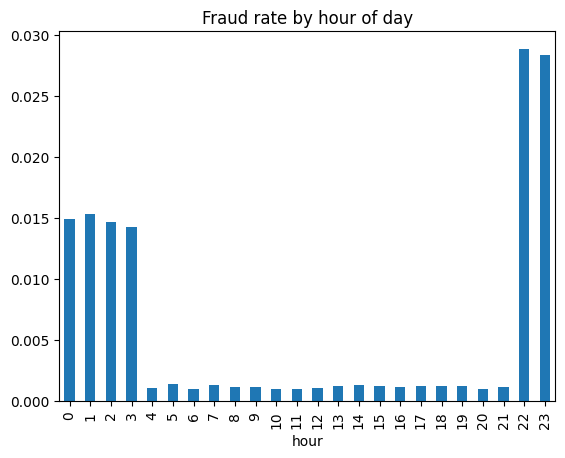

In [6]:
train["hour"] = train["trans_date_trans_time"].dt.hour
train.groupby("hour")["is_fraud"].mean().plot(kind="bar", title="Fraud rate by hour of day")